# Tutorial model run for the GeoEnthalpyDelta component.

Builds a small delta prograding from a west-edge feeder onto a planar,
fixed basement, with a flat sea level, then plots map-view thickness and a
centerline cross-section (bedrock, topography, sea level).

In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np

from landlab import RasterModelGrid
from landlab.components import GeoEnthalpyDelta

In [3]:
help(GeoEnthalpyDelta)

Help on class GeoEnthalpyDelta in module landlab.components.geoenthalpy_delta.geoenthalpy_delta:

class GeoEnthalpyDelta(landlab.core.model_component.Component)
 |  GeoEnthalpyDelta(
 |      grid,
 |      sediment_flux=0.5,
 |      feeder_width=1.0,
 |      feeder_y_center=None,
 |      sea_level_start=0.0,
 |      sea_level_rise_rate=0.0,
 |      topset_threshold_x=0.0,
 |      topset_threshold_y=0.0,
 |      foreset_threshold_x=2.0,
 |      foreset_threshold_y=2.0,
 |      topset_diffusivity_x=1.0,
 |      topset_diffusivity_y=1.0,
 |      foreset_diffusivity_x=1.0,
 |      foreset_diffusivity_y=1.0,
 |      cfl=0.4
 |  )
 |
 |  Simulate 2D sediment diffusion, transport, and deposition using an
 |  enthalpy formulation of a topset/foreset delta model.
 |
 |  This component is a structured Landlab wrapper around the core physics
 |  of a manuscript on 2D GeoEnthalpy-Delta modeling.
 |
 |  Sediment is supplied through a feeder with assigned width and is transported as a nonlinear,
 |  

Grid setup

In [2]:
nrows, ncols = 50, 50
dx = dy = 0.2
grid = RasterModelGrid((nrows, ncols), xy_spacing=dx) # hummm no option for (dx,dy)?

x = grid.x_of_node.reshape(grid.shape)
bedrock = grid.add_zeros("basement__elevation", at="node")
bedrock[:] = (-x).reshape(-1)  # planar, non-erodible basement E(x) = -x

Component calling

In [5]:
sea_level = -5.0
esd = GeoEnthalpyDelta(
    grid,
    sediment_influx=0.5,
    feeder_width=1.0,
    sea_level_start=sea_level,
    sea_level_rise_rate=0.1,
    topset_threshold_x=0.1,
    topset_threshold_y=0.1,
    foreset_threshold_x=2.0,
    foreset_threshold_y=2.0,
    topset_diffusivity_x=1.0,
    topset_diffusivity_y=1.0,
    foreset_diffusivity_x=1.0,
    foreset_diffusivity_y=1.0,
)

dt = esd.calc_stable_time_step()
nsteps = 5500
print(f"dt = {dt:.5g}, running {nsteps} steps (t_end = {nsteps * dt:.3g}) ...")

dt = 0.004, running 5500 steps (t_end = 22) ...


This will take a while, but your should see `done in #.# s` meaning the run is completed

In [6]:
t0 = time.time()
volume_history = []
time_history = []
for step in range(nsteps):
    esd.run_one_step(dt)
    if step % 25 == 0:
        vol = np.sum(grid.at_node["sediment__thickness"]) * dx * dy
        volume_history.append(vol)
        time_history.append(esd.time_elapsed)
print(f"done in {time.time() - t0:.2f} s")

done in 20.79 s


## Mass Balance
Checking if the final output match with the expected output

In [17]:
expected_volume = 0.5 * nsteps * dt
final_volume = np.sum(grid.at_node["sediment__thickness"]) * dx * dy
np.isclose(final_volume, expected_volume, rtol=1e-6)


np.True_

Check the 3 output of the component 
1. basement__elevation

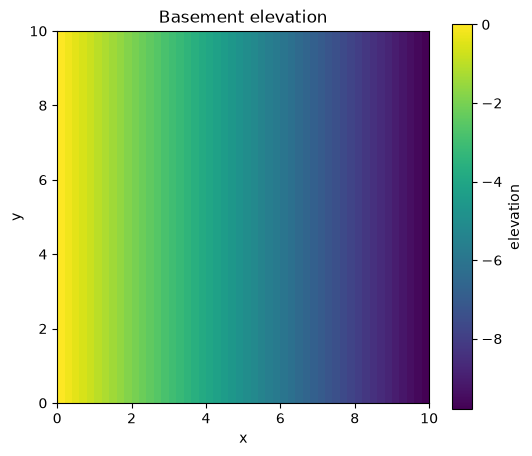

In [10]:
grid.at_node["basement__elevation"]
arr = grid.at_node["basement__elevation"].reshape(grid.shape)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(arr, origin="lower", extent=(0, ncols * dx, 0, nrows * dy),
               cmap="viridis", aspect="equal")
ax.set_title("Basement elevation (heatmap)")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(im, ax=ax, label="elevation")
plt.show()

2. `grid.at_node["sediment__thickness"]`


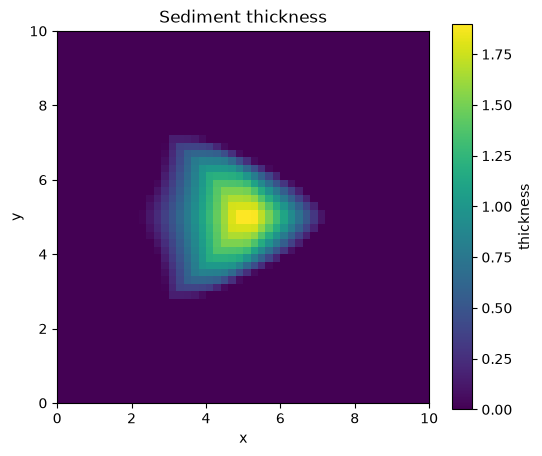

In [11]:
Hthickness = grid.at_node["sediment__thickness"].reshape(grid.shape)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(Hthickness, origin="lower", extent=(0, ncols * dx, 0, nrows * dy),
               cmap="viridis", aspect="equal")
ax.set_title("Sediment thickness")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(im, ax=ax, label="thickness")
plt.show()

3. `grid.at_node["topographic__elevation"]`

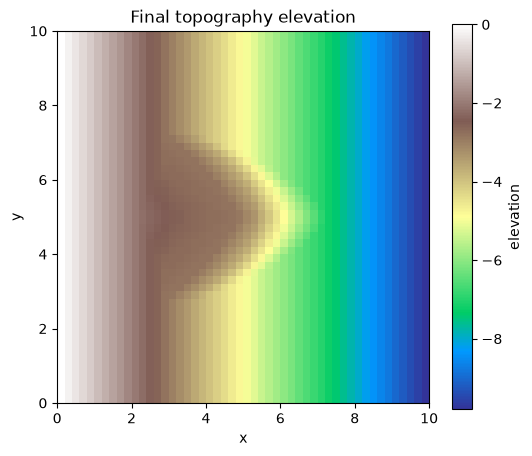

In [15]:
final_topography = grid.at_node["topographic__elevation"].reshape(grid.shape)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(final_topography, origin="lower", extent=(0, ncols * dx, 0, nrows * dy),
               cmap="terrain", aspect="equal")
ax.set_title("Final topography elevation")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(im, ax=ax, label="elevation")
plt.show()

## Comprehensive Plots

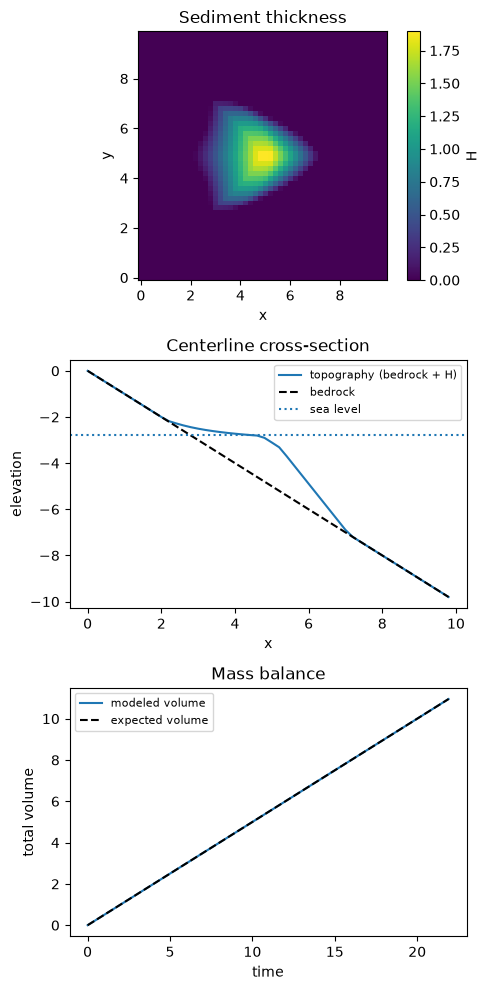

In [25]:
H = Hthickness
eta = final_topography
final_sea_level = sea_level + esd.sea_level_rise_rate * esd.time_elapsed
X = grid.x_of_node.reshape(grid.shape)
Y = grid.y_of_node.reshape(grid.shape)
j_mid = nrows // 2

fig, axes = plt.subplots(3, 1, figsize=(5, 10))

im = axes[0].pcolormesh(X, Y, H, shading="auto", cmap="viridis")
axes[0].set_title("Sediment thickness")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")
fig.colorbar(im, ax=axes[0], label="H")

axes[1].plot(X[j_mid], eta[j_mid], label="topography (bedrock + H)")
axes[1].plot(X[j_mid], basement[j_mid],
             "k--", label="bedrock")
axes[1].axhline(final_sea_level,color="tab:blue",linestyle=":",label="sea level")
axes[1].set_title("Centerline cross-section")
axes[1].set_xlabel("x")
axes[1].set_ylabel("elevation")
axes[1].legend(fontsize=8)

axes[2].plot(time_history, volume_history, label="modeled volume")
axes[2].plot(time_history, [0.5 * t for t in time_history], "k--", label="expected volume")
axes[2].set_title("Mass balance")
axes[2].set_xlabel("time")
axes[2].set_ylabel("total volume")
axes[2].legend(fontsize=8)

fig.tight_layout()